In [87]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
current_dir = Path.cwd()
project_root = current_dir.parents[2]

# EDA DATA V2

In [81]:
# --- Cargar datos ---
path_data1 = project_root / 'DATA_PPMI/Results/MODEL_DATA/DATA_BL_V08.csv'
path_data2=project_root / 'DATA_PPMI/Results/MODEL_DATA/DATA_test.csv'
path_data3=project_root / 'DATA_PPMI/Results/MODEL_DATA/DATA_test2.csv'

data_HY1 = pd.read_csv(path_data1)

data_HY1['PATNO']=data_HY1['PATNO'].apply(lambda x: str(x)+'_v1')
data_HY2 = pd.read_csv(path_data2) # stage2 only
data_HY2['PATNO']=data_HY2['PATNO'].apply(lambda x: str(x)+'_v2')
data_HY3 = pd.read_csv(path_data3) # stage2 only
data_HY3['PATNO']=data_HY3['PATNO'].apply(lambda x: str(x)+'_v3')

data_HY=pd.concat([data_HY1,data_HY2,data_HY3]).drop(columns=['Unnamed: 0'])

data_HY2['EVENT_ID']=data_HY2['EVENT_ID'].apply(lambda x: x+'_v2')
data_HY3['EVENT_ID']=data_HY3['EVENT_ID'].apply(lambda x: x+'_v3')

data_HY.head(10)

,PATNO,EVENT_ID,ENRLLRRK2,ENRLGBA,COHORT_DEFINITION,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCAALTTM,...,NP3PTRML,NP3KTRMR,NP3KTRML,NP3RTARU,NP3RTALU,NP3RTARL,NP3RTALL,NP3RTALJ,NP3RTCON,NHY
0,3003_v1,BL,0,0,Parkinson's Disease,0.0,1.0,16.0,56.7,1.0,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
1,3003_v1,V04,0,0,Parkinson's Disease,0.0,1.0,16.0,57.7,1.0,...,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0
2,3003_v1,V06,0,0,Parkinson's Disease,0.0,1.0,16.0,58.8,1.0,...,1.0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0
3,3003_v1,V08,0,0,Parkinson's Disease,0.0,1.0,16.0,59.7,0.0,...,0.0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0
4,3018_v1,BL,0,0,Parkinson's Disease,0.0,1.0,16.0,60.5,1.0,...,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0,2.0
5,3018_v1,V04,0,0,Parkinson's Disease,0.0,1.0,16.0,61.6,1.0,...,2.0,2.0,1.0,3.0,1.0,0.0,0.0,0.0,3.0,2.0
6,3018_v1,V06,0,0,Parkinson's Disease,0.0,1.0,16.0,62.9,1.0,...,0.0,2.0,0.0,3.0,0.0,0.0,0.0,0.0,4.0,2.0
7,3018_v1,V08,0,0,Parkinson's Disease,0.0,1.0,16.0,63.6,0.0,...,1.0,0.0,0.0,2.0,1.0,1.0,0.0,0.0,3.0,2.0
8,3020_v1,BL,0,0,Parkinson's Disease,0.0,1.0,15.0,74.0,1.0,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,2.0
9,3020_v1,V04,0,0,Parkinson's Disease,0.0,1.0,15.0,75.0,1.0,...,0.0,0.0,0.0,3.0,0.0,2.0,0.0,0.0,2.0,2.0


In [82]:
# 1) Normaliza cohortes a etiquetas cortas

# 2) Filtra a las cohortes y visitas que quieres
visits = ["BL", "V04", "V06", "V08","V10","V12"]


data_HY = data_HY[
    data_HY["COHORT_DEFINITION"].isin(["Parkinson's Disease", "Prodromal"]) &
    data_HY["EVENT_ID"].isin(visits)
].copy()

# 3) Asegura NHY 0-5 (por si viene como 0.0/1.0)
data_HY = data_HY[data_HY["NHY"].isin([0,1,2,3,4,5])].copy()
data_HY["NHY"] = data_HY["NHY"].astype(int)

# 4) Tabla pivote de conteos
tab = (
    data_HY.groupby(["EVENT_ID", "COHORT_DEFINITION", "NHY"])
      .size()
      .unstack("NHY", fill_value=0)
      .reindex(columns=[0,1,2,3,4,5], fill_value=0)
)

# 5) Total por fila
tab["Total"] = tab.sum(axis=1)

tab

NHY                             0    1    2   3  4  5  Total
EVENT_ID COHORT_DEFINITION                                  
BL       Parkinson's Disease    1  145  266   7  0  0    419
         Prodromal            461   20    9   0  0  0    490
V04      Parkinson's Disease    2  168  482  26  3  0    681
         Prodromal            669   36   30   1  0  0    736
V06      Parkinson's Disease    2  176  655  35  7  0    875
         Prodromal            857   32   40   6  0  0    935
V08      Parkinson's Disease    0  136  693  38  5  3    875
         Prodromal            807   70   57   1  0  0    935
V10      Parkinson's Disease    4   59  351  38  2  2    456
         Prodromal            403   24   15   3  0  0    445
V12      Parkinson's Disease    1   11  162  16  2  2    194
         Prodromal            181   12    5   0  1  0    199

In [83]:
def HY_classification(nhy):
    if nhy == 0 :
        return 'Healthy'
    elif nhy in [1,2] :
        return 'Early Stage'
    else:
        return 'Advanced Stage'

data_HY1['STAGE'] = data_HY1['NHY'].apply(HY_classification)
data_HY2['STAGE'] = data_HY2['NHY'].apply(HY_classification)
data_HY2=data_HY2.loc[(data_HY2['EVENT_ID']=='V10_v2') & (data_HY2['STAGE']=='Advanced Stage'), :]
data_HY3['STAGE'] = data_HY3['NHY'].apply(HY_classification)
data_HY3=data_HY3.loc[(data_HY3['EVENT_ID']=='V12_v3') & (data_HY3['STAGE']=='Advanced Stage'), :]

data_HY_v2=pd.concat([data_HY1,data_HY2,data_HY3]).drop(columns=['Unnamed: 0'])
data_HY_v2

,PATNO,EVENT_ID,ENRLLRRK2,ENRLGBA,COHORT_DEFINITION,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCAALTTM,...,NP3KTRMR,NP3KTRML,NP3RTARU,NP3RTALU,NP3RTARL,NP3RTALL,NP3RTALJ,NP3RTCON,NHY,STAGE
0,3003_v1,BL,0,0,Parkinson's Disease,0.0,1.0,16.0,56.7,1.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Early Stage
1,3003_v1,V04,0,0,Parkinson's Disease,0.0,1.0,16.0,57.7,1.0,...,2.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0,Early Stage
2,3003_v1,V06,0,0,Parkinson's Disease,0.0,1.0,16.0,58.8,1.0,...,2.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0,Early Stage
3,3003_v1,V08,0,0,Parkinson's Disease,0.0,1.0,16.0,59.7,0.0,...,2.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0,Early Stage
4,3018_v1,BL,0,0,Parkinson's Disease,0.0,1.0,16.0,60.5,1.0,...,0.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0,2.0,Early Stage
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867,51551_v3,V12_v3,0,1,Parkinson's Disease,0.0,1.0,15.0,57.4,1.0,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,3.0,Advanced Stage
887,51844_v3,V12_v3,0,1,Parkinson's Disease,0.0,1.0,18.0,85.8,1.0,...,1.0,2.0,0.0,2.0,0.0,2.0,2.0,2.0,3.0,Advanced Stage
1027,56169_v3,V12_v3,1,0,Prodromal,0.0,1.0,19.0,84.1,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,Advanced Stage
1031,56435_v3,V12_v3,0,1,Parkinson's Disease,1.0,1.0,16.0,64.9,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,Advanced Stage


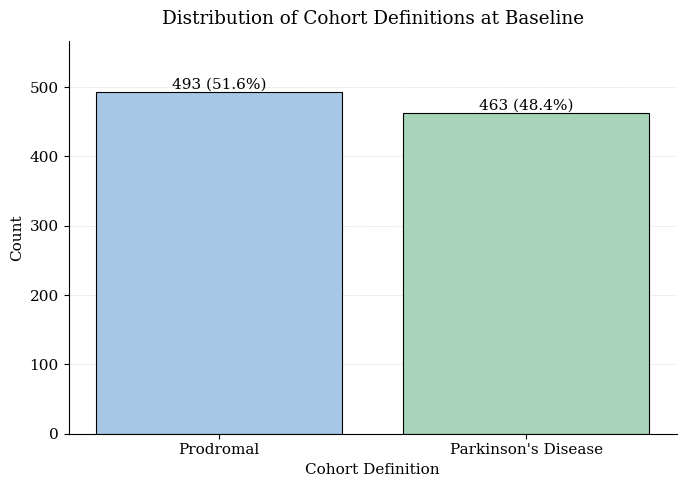

In [84]:

# Filtrar y contar
counts = (
    data_HY_v2.loc[data_HY_v2['EVENT_ID'].isin(['BL','V10_v2','V12_v3']), 'COHORT_DEFINITION']
    .value_counts()
)

total = counts.sum()
percentages = counts / total * 100

# Definir colores específicos
color_map = {
    "Prodromal": "#A7C7E7",   # azul pastel
    "Parkinson": "#A8D5BA"    # verde pastel
}

colors = [color_map.get(cat, "#A8D5BA") for cat in counts.index]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    counts.index,
    counts.values,
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

# Añadir count + porcentaje encima
for bar, count, pct in zip(bars, counts.values, percentages):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{count} ({pct:.1f}%)",
        ha='center',
        va='bottom'
    )

ax.set_title("Distribution of Cohort Definitions at Baseline", pad=12)
ax.set_xlabel("Cohort Definition")
ax.set_ylabel("Count")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)

plt.xticks(rotation=0)

# Añadir pequeño margen superior para que no se corte el texto
ax.set_ylim(0, max(counts.values) * 1.15)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1403677/492311183.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts_df['Stage'], rotation=0, ha='center')


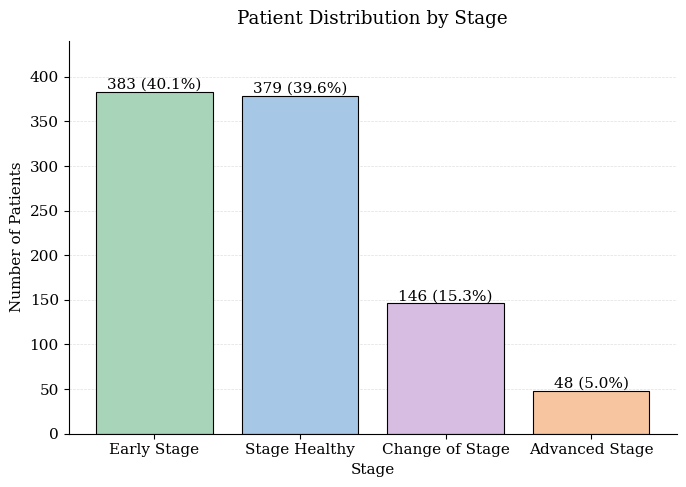

In [85]:
counts = {'Stage Healthy': 0, 'Early Stage': 0, 'Advanced Stage': 0,'Change of Stage': 0}
for patno in data_HY_v2['PATNO'].unique():
    subset_data = data_HY_v2[data_HY_v2['PATNO'] == patno]
    stages = subset_data['STAGE'].unique()
    
    if len(stages) > 1:
        counts['Change of Stage'] += 1
    else:
        if stages[0] == 'Healthy':
            counts['Stage Healthy'] += 1
        elif stages[0] == 'Early Stage':
            counts['Early Stage'] += 1
        elif stages[0] == 'Advanced Stage':
            counts['Advanced Stage'] += 1


# Convertir a DataFrame
counts_df = pd.DataFrame(list(counts.items()), columns=['Stage', 'Count'])

# (Opcional) ordenar por conteo descendente
counts_df = counts_df.sort_values('Count', ascending=False)

total = counts_df['Count'].sum()
counts_df['Pct'] = counts_df['Count'] / total * 100

# Colores pastel por categoría (ajusta a tu gusto)
color_map = {
    "Stage Healthy": "#A7C7E7",      # azul pastel
    "Early Stage": "#A8D5BA",        # verde pastel
    "Advanced Stage": "#F7C59F",     # naranja pastel
    "Change of Stage": "#D7BDE2"     # lila pastel
}
colors = [color_map.get(cat, "#D3D3D3") for cat in counts_df['Stage']]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    counts_df['Stage'],
    counts_df['Count'],
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

# Añadir count + porcentaje encima de cada barra
for bar, count, pct in zip(bars, counts_df['Count'], counts_df['Pct']):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{count} ({pct:.1f}%)",
        ha='center',
        va='bottom'
    )

ax.set_title("Patient Distribution by Stage", pad=12)
ax.set_xlabel("Stage")
ax.set_ylabel("Number of Patients")

# Estilo de ejes como tu ejemplo
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)

# Rotación de etiquetas (pon 0 si te caben bien)
ax.set_xticklabels(counts_df['Stage'], rotation=0, ha='center')

# Margen arriba para que no se corte el texto
ax.set_ylim(0, counts_df['Count'].max() * 1.15)

plt.tight_layout()
plt.show()

# STATISTICAL DESCRIPTION

## AGE

## SEX

## RACE

## EDUCATION_YEARS

In [86]:
data_HY_v2

,PATNO,EVENT_ID,ENRLLRRK2,ENRLGBA,COHORT_DEFINITION,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCAALTTM,...,NP3KTRMR,NP3KTRML,NP3RTARU,NP3RTALU,NP3RTARL,NP3RTALL,NP3RTALJ,NP3RTCON,NHY,STAGE
0,3003_v1,BL,0,0,Parkinson's Disease,0.0,1.0,16.0,56.7,1.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Early Stage
1,3003_v1,V04,0,0,Parkinson's Disease,0.0,1.0,16.0,57.7,1.0,...,2.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0,Early Stage
2,3003_v1,V06,0,0,Parkinson's Disease,0.0,1.0,16.0,58.8,1.0,...,2.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0,Early Stage
3,3003_v1,V08,0,0,Parkinson's Disease,0.0,1.0,16.0,59.7,0.0,...,2.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0,Early Stage
4,3018_v1,BL,0,0,Parkinson's Disease,0.0,1.0,16.0,60.5,1.0,...,0.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0,2.0,Early Stage
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867,51551_v3,V12_v3,0,1,Parkinson's Disease,0.0,1.0,15.0,57.4,1.0,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,3.0,Advanced Stage
887,51844_v3,V12_v3,0,1,Parkinson's Disease,0.0,1.0,18.0,85.8,1.0,...,1.0,2.0,0.0,2.0,0.0,2.0,2.0,2.0,3.0,Advanced Stage
1027,56169_v3,V12_v3,1,0,Prodromal,0.0,1.0,19.0,84.1,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,Advanced Stage
1031,56435_v3,V12_v3,0,1,Parkinson's Disease,1.0,1.0,16.0,64.9,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,Advanced Stage
